Same code like the other test fit file, but separated since the outputs are long. 

In [1]:
#Code cell adapted from 1d_energy_comparison.ipynb in the pvqz_basis_set_comparison folder
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy.optimize import curve_fit
hartree_to_cm = 219474.63

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])

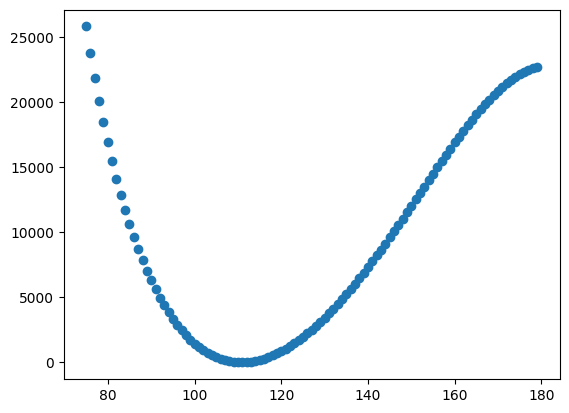

In [6]:
aopo_coords, E_aopo = load_coords_energy('aopo_1d.txt')
aopo = aopo_coords[:,3]*np.pi/180
w = (np.tanh(-0.008*(E_aopo - 2000)) + 1.002002002) / 2.002002002
#print(aopo)
#print(E_aopo)

plt.figure()
plt.plot(aopo*180/np.pi, E_aopo, 'o')
#plt.xlim(100,130)
#plt.ylim(-0.5, 1000)

In [7]:
def power_term(x, xe):
    #return np.cos(x) - np.cos(xe)
    return x - xe

def cos_term(x, xe):
    return np.cos(x) - np.cos(xe)

def power_series(x, xe, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    z = power_term(x, xe)
    c = [c0, c1, c2, c3, c4, c5, c6, c7, c8]
    series = 0
    for i in range(9):
        series += c[i]*z**(i)

    return series 

def cos_series(x, xe, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    z = cos_term(x, xe)
    c = [c0, c1, c2, c3, c4, c5, c6, c7, c8]
    series = 0
    for i in range(9):
        series += c[i]*z**(i)

    return series 

def rmsd(obs, calc, weight):
    squared_diff = (obs-calc)**2
    weighted_mean_sqr = np.sum(weight*squared_diff)/np.sum(weight)
    return np.sqrt(weighted_mean_sqr)

def fit_evaluation(function, param_guess, weights):
    """This function fits a function to the bending energy data with given
       input parameters and given weights. Uses SciPy curvefit"""
    
    #perform fit
    p, cov = curve_fit(function, aopo, E_aopo, 
                       param_guess, 
                       sigma = 1/np.sqrt(weights))
    
    #print parameters obtained from fit
    print('Parameter Values:')
    print(np.round(p, 5))
    print()
    print('Parameter Error (%)')
    print(np.round(
    (np.sqrt(np.diag(cov))/p*100),
     3))
    
    #unpack parameters to predict energy, print RMSD 
    function_predict = function(aopo, *p)
    print()
    print(f'The RMSD is {rmsd(E_aopo, function_predict, weights)} cm-1')
    print()

    #print residuals
    with np.printoptions(precision=3, suppress=True, linewidth=100):
        print('Residuals:')
        print(E_aopo - function_predict)
    #leave space for plotting
    for i in range(3):
        print()
    #plot fit, calculations and residuals
    plt.figure()
    plt.plot(aopo*180/np.pi, function_predict)
    plt.plot(aopo*180/np.pi, E_aopo, '.')

    plt.figure()
    plt.plot(aopo*180/np.pi, E_aopo - function_predict)
    


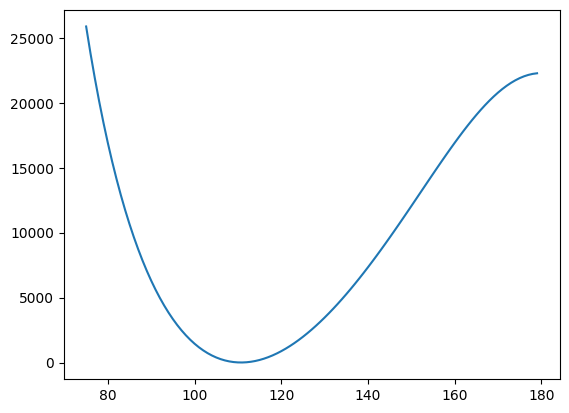

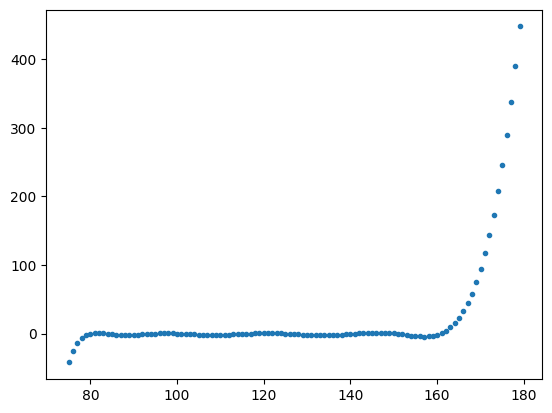

In [13]:
w = (np.tanh(-0.008*(E_aopo - 20000)) + 1.002002002) / 2.002002002

original_params =   [110.72601336*np.pi/180, 1.1272906, 0, 41551.184, 9732.8572, 
                     35515.598, 14891.674, 7424.2550,
                     -4611.0165, 75686.084]
original_fit = cos_series(aopo, *original_params)

plt.figure()
plt.plot(aopo*180/np.pi, original_fit)

plt.figure()
plt.plot(aopo*180/np.pi, E_aopo - original_fit, '.')

In [15]:
print(f'The RMSD is {rmsd(E_aopo, original_fit, w)} cm-1')
print()

with np.printoptions(precision=3, suppress=True, linewidth=100):
    print('Residuals:')
    print(E_aopo - original_fit)

The RMSD is 7.322457148429709 cm-1

Residuals:
[-42.222 -25.74  -14.462  -7.129  -2.711  -0.372   0.558   0.6     0.15   -0.502  -1.157  -1.689
  -2.032  -2.165  -2.1    -1.87   -1.523  -1.111  -0.685  -0.293   0.028   0.252   0.363   0.357
   0.239   0.023  -0.268  -0.609  -0.971  -1.327  -1.648  -1.913  -2.103  -2.205  -2.213  -2.128
  -1.956  -1.709  -1.403  -1.058  -0.698  -0.344  -0.019   0.256   0.463   0.589   0.626   0.568
   0.419   0.186  -0.119  -0.479  -0.874  -1.28   -1.674  -2.032  -2.33   -2.548  -2.672  -2.688
  -2.593  -2.386  -2.077  -1.679  -1.212  -0.703  -0.182   0.318   0.764   1.121   1.359   1.453
   1.382   1.138   0.721   0.142  -0.571  -1.378  -2.225  -3.043  -3.747  -4.239  -4.408  -4.131
  -3.274  -1.69    0.776   4.29    9.033  15.193  22.974  32.598  44.301  58.336  74.977  94.513
 117.244 143.479 173.525 207.677 246.204 289.338 337.255 390.06  447.776]


Test one morse term fit:

Parameter Values:
[1.94850000e+00 2.45722237e+07 4.54800000e-02]

Parameter Error (%)
[  0.199 143.83   72.045]

The RMSD is 487.53431306563584 cm-1

Residuals:
[5237.568 4301.568 3478.443 2757.975 2130.655 1587.655 1120.804  722.548  385.916  104.489 -127.646
 -315.919 -465.32  -580.424 -665.425 -724.159 -760.136 -776.556 -776.341 -762.145 -736.383 -701.243
 -658.701 -610.542 -558.37  -503.62  -447.572 -391.361 -335.989 -282.329 -231.142 -183.075 -138.676
  -98.398  -62.605  -31.578   -5.521   15.435   31.225   41.847   47.36    47.873   43.55    34.597
   21.267    3.85   -17.329  -41.911  -69.506  -99.702 -132.062 -166.126 -201.422 -237.461 -273.742
 -309.757 -344.992 -378.93  -411.054 -440.849 -467.809 -491.432 -511.232 -526.734 -537.484 -543.048
 -543.014 -537.    -524.655 -505.66  -479.736 -446.644 -406.192 -358.235 -302.681 -239.492 -168.692
  -90.366   -4.662   88.204  187.946  294.209  406.571  524.539  647.555  775.     906.196 1040.418
 1176.898 1314.839 1453.423 1591.825 17

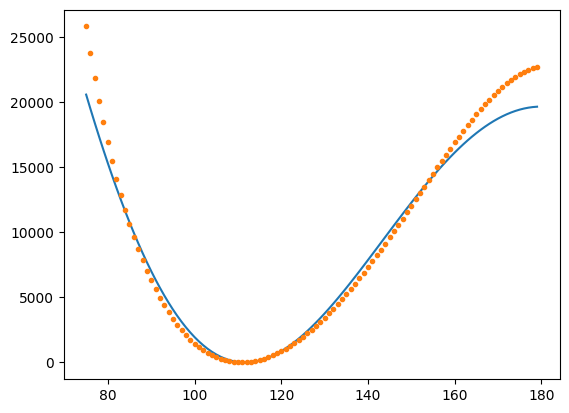

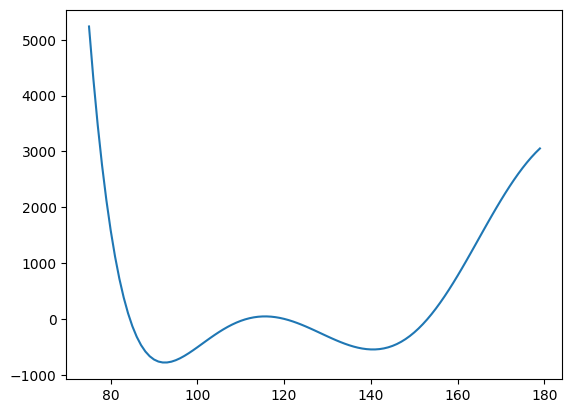

In [23]:
#try fitting only one morse-like term
def morse_like(x, xe, b):
    return 1 - np.exp(b*(np.cos(x)-np.cos(xe)))


weight_morse_test = (np.tanh(-0.008*(E_aopo - 18000)) + 1.002002002) / 2.002002002
fit_evaluation(lambda x, xe, a, b: a*morse_like(x, xe, b)**2, 
               [110.72601336*np.pi/180, 
                2e7, 
                0.17], 
                weight_morse_test)

Parameter Values:
[ 1.93271000e+00  2.28860177e+08  2.65600000e+00 -3.77776071e+05
  1.52884291e+05  1.32787425e+05 -7.00244562e+04  3.11290783e+03]

Parameter Error (%)
[ 4.0000e-03  4.6100e+00  3.3976e+01 -5.0450e+00  5.2920e+00  3.7850e+00
 -3.0700e+00  6.2010e+00]

The RMSD is 4.029477063982848 cm-1

Residuals:
[148.811 102.773  67.697  41.642  22.89    9.95    1.543  -3.412  -5.815  -6.409  -5.789  -4.431
  -2.7    -0.872   0.855   2.346   3.519   4.332   4.777   4.871   4.65    4.159   3.454   2.593
   1.633   0.632  -0.36   -1.298  -2.142  -2.862  -3.435  -3.846  -4.087  -4.157  -4.061  -3.811
  -3.422  -2.914  -2.309  -1.632  -0.908  -0.163   0.578   1.29    1.951   2.54    3.039   3.433
   3.711   3.865   3.889   3.784   3.553   3.201   2.739   2.181   1.543   0.845   0.108  -0.645
  -1.387  -2.094  -2.74   -3.298  -3.745  -4.059  -4.221  -4.216  -4.032  -3.666  -3.119  -2.402
  -1.532  -0.537   0.545   1.665   2.766   3.776   4.618   5.203   5.436   5.219   4.455   3.051
   0

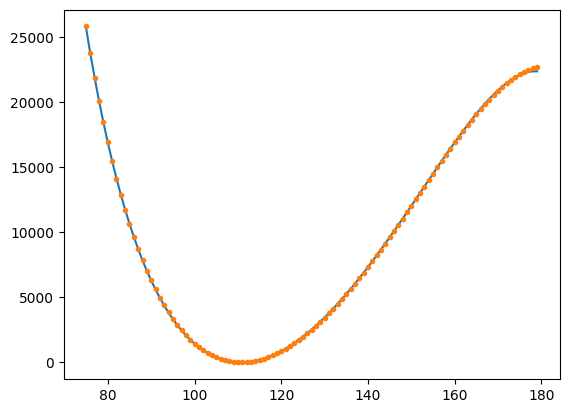

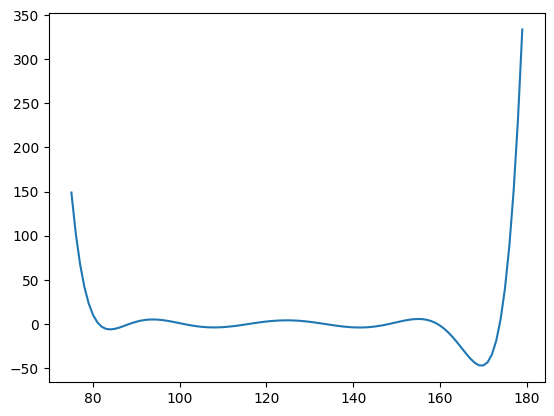

In [32]:
def morse_polynomial(x, xe, a, c0, c2, c3, c4, c5, c6):
    series = a*morse_like(x, xe, 4.54800000e-02)**2
    c = [c0, c2, c3, c4, c5, c6]
    powers = [0, 2, 3, 4, 5, 6]
    for j in range(len(c)):
        series += c[j]*power_term(x, xe)**powers[j]
    return series

weight_morse_poly = (np.tanh(-0.008*(E_aopo - 18000)) + 1.002002002) / 2.002002002
fit_evaluation(morse_polynomial, 
              [110.72601336*np.pi/180, 
               2.45722237e+07, 
                        8.832,
                        -8.50993381e+03,
                        -3.55430498e+03,
                        3.53242469e+04,
                        -2.84906227e+04,
                        6.22003155e+03],
                weight_morse_poly)

Parameter Values:
[ 1.93112000e+00  4.35147400e+01  1.90093769e+07 -1.13434349e+08
  1.17775161e+10]

Parameter Error (%)
[ 0.026 20.215  0.393 -2.565  1.093]

The RMSD is 44.31387382191114 cm-1

Residuals:
[ 691.085  488.225  329.6    208.215  117.832   52.928    8.66   -19.194  -34.275  -39.7    -38.105
  -31.693  -22.282  -11.344   -0.043   10.722   20.289   28.195   34.151   38.014   39.761   39.466
   37.283   33.425   28.146   21.731   14.479    6.694   -1.324   -9.288  -16.934  -24.02   -30.334
  -35.698  -39.967  -43.035  -44.829  -45.315  -44.49   -42.389  -39.075  -34.641  -29.205  -22.908
  -15.91    -8.385   -0.52     7.492   15.453   23.167   30.44    37.09    42.945   47.847   51.658
   54.263   55.569   55.511   54.053   51.188   46.943   41.374   34.572   26.659   17.79     8.149
   -2.051  -12.569  -23.142  -33.486  -43.3    -52.27   -60.074  -66.387  -70.888  -73.261  -73.204
  -70.435  -64.698  -55.763  -43.441  -27.578   -8.066   15.156   42.103   72.74   106.986  1

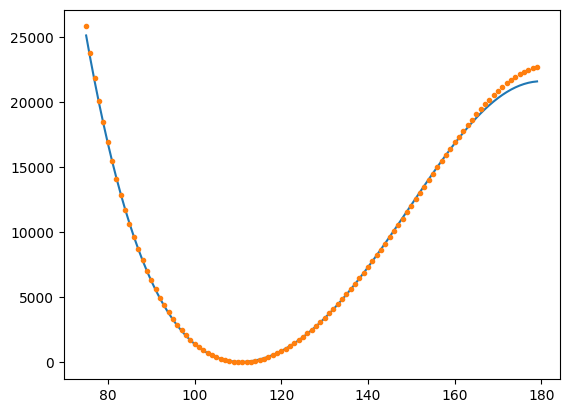

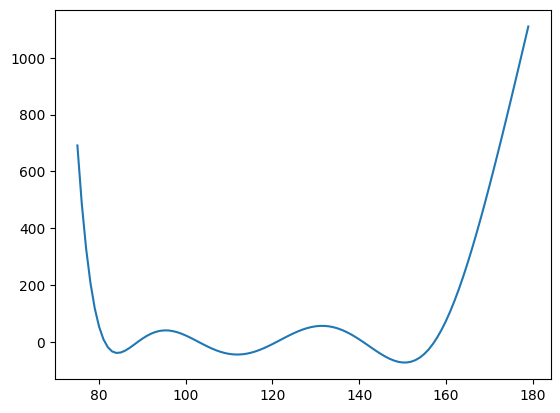

In [35]:
def morse_quartic(x, xe, c0, c2, c3, c4):
    series = c0
    c = [c2, c3, c4]
    powers = [2, 3, 4]
    for j in range(len(c)):
        series += c[j]*morse_like(x, xe, 4.54800000e-02)**powers[j]
    return series

weight_morse_quartic = (np.tanh(-0.008*(E_aopo - 18000)) + 1.002002002) / 2.002002002
fit_evaluation(morse_quartic, 
              [1.98400000e+00,
               1.68051900e+01, 
               1.30691808e+05,
               1.38435356e+05,
               8.67869692e+05],
                weight_morse_quartic)

Parameter Values:
[ 1.93249000e+00  3.48717667e+06  1.88010000e-01  1.02474000e+00
 -8.18100667e+04 -1.32876238e+04  3.49365740e+04  1.31475335e+04
 -4.90592858e+03 -3.62212490e+02  9.99038496e+04]

Parameter Error (%)
[ 5.00000000e-03  2.52575495e+05  1.86997590e+04  7.90370000e+01
 -3.80506923e+05 -4.44034638e+05  1.87682790e+04  4.09112400e+03
 -7.42542000e+02 -1.06007100e+03  7.12000000e+00]

The RMSD is 3.1398809971361814 cm-1

Residuals:
[-146.532  -97.399  -61.857  -36.932  -20.139   -9.425   -3.116    0.128    1.356    1.368    0.753
   -0.076   -0.848   -1.407   -1.682   -1.669   -1.403   -0.947   -0.378    0.227    0.798    1.276
    1.618    1.797    1.805    1.649    1.347    0.931    0.437   -0.092   -0.615   -1.093   -1.492
   -1.783   -1.947   -1.975   -1.866   -1.627   -1.277   -0.837   -0.337    0.193    0.717    1.204
    1.623    1.948    2.158    2.239    2.184    1.994    1.68     1.256    0.746    0.178   -0.416
   -1.      -1.54    -2.003   -2.359   -2.582   -2.6

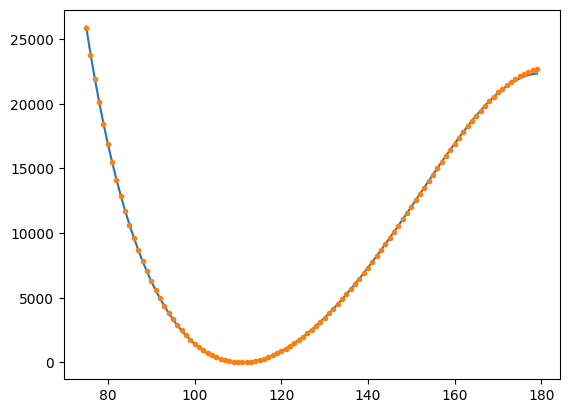

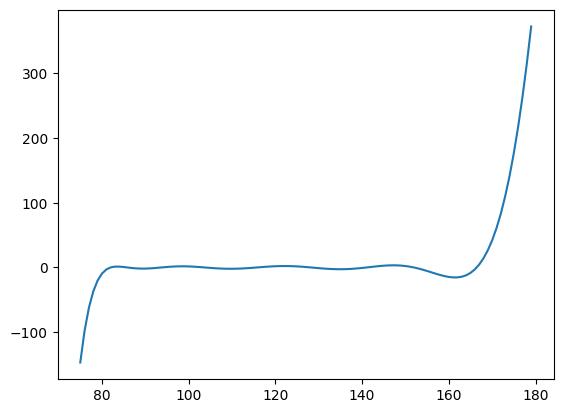

In [40]:
def cosine_morse(x, xe, a, b, c0, c2, c3, c4, c5, c6, c7, c8):
    series = a*morse_like(x, xe, b)**2
    c = [c0, c2, c3, c4, c5, c6, c7, c8]
    powers = [0, 2, 3, 4, 5, 6, 7, 8]
    for j in range(len(c)):
        series += c[j]*cos_term(x, xe)**powers[j]
    return series

weight_cos_morse = (np.tanh(-0.008*(E_aopo - 15000)) + 1.002002002) / 2.002002002
fit_evaluation(cosine_morse, 
              [1.97286000e+00,
               2.95801752e+06,
               2.15830000e-01,
               -6.11390000e-01,
               -1.05940528e+05,
               6.64804725e+04,
               1.67903816e+04,
               -1.93738806e+04,
               3.82628858e+03,
               0,
               0],
               weight_cos_morse)